In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Clone the repository
!git clone https://github.com/benpsutton/water_hyacinth_code.git

# Change into the repo
%cd /content/water_hyacinth_code/

# Install extra packages (if needed)
!pip install torchmetrics kornia

Mounted at /content/drive
Cloning into 'water_hyacinth_code'...
remote: Enumerating objects: 490, done.
remote: Counting objects: 100% (490/490), done.
remote: Compressing objects: 100% (280/280), done.
remote: Total 490 (delta 301), reused 380 (delta 199), pack-reused 0 (from 0)
Receiving objects: 100% (490/490), 10.67 MiB | 21.80 MiB/s, done.
Resolving deltas: 100% (301/301), done.
/content/water_hyacinth_code
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 99.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchmetrics
import kornia.augmentation as K

In [3]:
drive_root = Path("/content/drive/MyDrive")

PROJECT_ROOT = Path().resolve().parent
datetime_now = datetime.datetime.now()
date = datetime_now.strftime("%Y-%m-%d")

# loss_curve_fp = PROJECT_ROOT / "outputs/plots" / f"loss_curve_{date}.png"

# for on colab
loss_curve_fp = drive_root / "Dissertation" / "15px_patches"/ f"loss_curve_{date}.png"

In [ ]:
# def load_patch_dict_as_tensor(Patch_dict):

#     # try first as a for loop and then see if can switch to comprehension

#     band_names = ["B2", "B3", "B4", "B5", "B6"]

#     feature_list = Patch_dict["features"]

#     patch_list = []0
#     label_list = []
#     location_list = []

#     for feat in feature_list:

#         band_arrays = [np.array(feat["properties"][band]) for band in band_names]
#         stacked_patch = np.stack(band_arrays) # (C,H,W)

#         patch_list.append(stacked_patch)
#         label_list.append(feat["properties"]["lc"])
#         location_list.append(feat["properties"]["location"])

#     patches = np.stack(patch_list) # (N, C, H, W)
#     patches = torch.from_numpy(patches).float()

#     labels= torch.tensor(label_list).long()
#     locations = np.array(location_list) # array for easier boolean masking but no need for tensor


#     return patches, labels, locations

In [19]:
# patches_path = PROJECT_ROOT / "outputs/15px_patches" / "combined_15px_patches.geojson"

# for on colab
patches_path = drive_root / "Dissertation" / "15px_patches" / "combined_15px_patches.geojson"
with open(patches_path, "r") as f:
    patches = json.load(f)


In [21]:
# Version using comprehension

def load_patch_dict_as_tensor(Patch_dict, band_list = None):
    if not band_list:
        band_list = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "AWEIp95", "B11", "B12"]

    feature_list = Patch_dict["features"]

    patches = np.stack([
        np.stack([np.array(F["properties"][band]) for band in band_list]) # (N, C, H, W) which is what pytorch expects
        for F in feature_list
    ])

    labels = torch.tensor([F["properties"]["lc"] for F in feature_list]).float().unsqueeze(1) # BCElogits loss will need to compare labels to float logits or probabilties
    # .unsqueeze(1) changes the shape from ([0,1,1,0]) to ([0],[1],[1],[0]) aka (B,) to (B, 1), need this for the criterion.

    locations = np.array([F["properties"]["location"] for F in feature_list]) # array for easier boolean masking but no need for tensor

    patches = torch.from_numpy(patches).float()


    return patches, labels, locations

patches, labels, locations = load_patch_dict_as_tensor(patches, band_list= None)

# check the shape

print(patches.shape)


torch.Size([16189, 10, 15, 15])


In [7]:
print(labels.shape)
print(labels[12000])

torch.Size([16189, 1])
tensor([0.])


In [22]:
# next need to calcualte the mean and std for just the train region, can create a test_mask and val_mask and then train_masl = ~test_mask & ~val_mask

test_region = "Vembanad"
val_region = "Hartbeespoort"

test_mask = locations == test_region
val_mask = locations == val_region

train_mask = ~test_mask & ~ val_mask

train_patches, train_labels = patches[train_mask], labels[train_mask]
val_patches, val_labels = patches[val_mask], labels[val_mask]
test_patches, test_labels = patches[test_mask], labels[test_mask]


mean = train_patches.mean(dim= (0,2,3)) # will average over the 0,2,3 axes and keep the 1 axis (channels / bands) separate. output shape (C,)
std = train_patches.std(dim = (0,2,3))

# mean = torch.tensor(mean).view(1,-1,1,1) # changes mean from (C,) to (1,C,1,1)
# std = torch.tensor(std).view(1,-1,1,1)

# standardise all the patches using the mean and std from the train patches - np maybe do this for each patch in the dataset in __getitem__?

# std_train_patches = (train_patches - mean)/std
# std_val_patches = (val_patches-mean)/std
# std_test_patches = (test_patches-mean)/ std




In [24]:

class PatchDataset(Dataset):
    def __init__(self, patches, labels, mean, std):

        mean = mean.detach().clone().view(1,-1,1,1) # changes from (C,) to (1,C,1,1)
        std = std.detach().clone().view(1,-1,1,1)

        self.patches = (patches - mean)/std
        self.labels = labels

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        return self.patches[idx], self.labels[idx]




train_dataset = PatchDataset(patches = train_patches, labels = train_labels, mean = mean, std = std)

train_loader = DataLoader(
    dataset= train_dataset,
    shuffle= True,
    batch_size= 32,
    num_workers= 2,
    pin_memory= True
    )

val_dataset = PatchDataset(patches = val_patches,labels= val_labels, mean = mean, std = std)

val_loader = DataLoader(
    dataset= val_dataset,
    shuffle= True,
    batch_size= 32,
    num_workers= 2,
    pin_memory= True
    )

# # --- Device selection ---
# # Colab (with a GPU runtime: Runtime > Change runtime type > GPU):
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Apple Silicon (M1/M2/M3/M4), using the Metal Performance Shaders backend:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Portable version that works on either without editing — checks cuda, then mps, then falls back to cpu:

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

aug = K.AugmentationSequential(
    K.RandomRotation(degrees = 90.0, p =0.5),
    K.RandomHorizontalFlip(p= 0.25),
    K.RandomVerticalFlip(p= 0.25),
    data_keys= ['input']).to(device)

# for epoch in len(number_epochs):
#     # Training
#     #-----------------------
#     model.train()

#     for batch_X, batch_y in train_loader:
#         batch_X = batch_X.to(device)
#         batch_y = batch_y.to(device)

#         batch_X = aug(batch_X) # Augment only in the train split

#         optimizer.zero_grad()
#         output = model(batch_x)
#         loss = criterion(output, batch_y)
#         loss.backwards()
#         optimizer.step()

#     # Val
#     #-----------------------

#     model.eval()

#     with torch.no_grad():
#         for batch_X, batch_y in val_loader:

#             batch_X = batch_X.to(device)
#             batch_y = batch_y.to(device)

#             output = model(batch_x)
#             val_loss = criterion(output, batch_y)

    # Plot?

In [10]:
# Define my model

input_channels = 10


myCNN = nn.Sequential(
    nn.Conv2d(in_channels=input_channels,
            out_channels = 32,
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32,
            out_channels = 32,
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
        nn.Conv2d(in_channels=32,
            out_channels = 64,
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(in_channels=64,
            out_channels = 64,
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    #nn.Dropout(0.5) wont have this for now
    nn.Linear(64,1)
)

In [11]:
# metrics - use torchmetrics to make a metric collection that is a dictionary of metrics

num_classes = 2

metrics = torchmetrics.MetricCollection({
    "accuracy": torchmetrics.classification.BinaryAccuracy(),
    "f1": torchmetrics.classification.BinaryF1Score(),
    "precision": torchmetrics.classification.BinaryPrecision(),
    "recall": torchmetrics.classification.BinaryRecall(),
    "auroc": torchmetrics.classification.BinaryAUROC()
}).to(device)

In [25]:
def train_for_one_epoch(model, train_loader, device, aug, optimizer, criterion):

    model.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        batch_X = aug(batch_X) # Augment only in the train split

        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*batch_X.size(0)
    avg_loss = running_loss / len(train_loader.dataset)

    return avg_loss


def val_for_one_epoch(model, val_loader, metrics, device, criterion):

    model.eval()
    running_val_loss = 0.0
    metrics.reset() # clears the metrics from previous epochs

    with torch.no_grad():
        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)               # Outputting logits as useing BCEntropy with logit loss as criterion
            val_loss = criterion(logits, batch_y)

            #probs = torch.sigmoid(logits) # gives probabilities between 0 and 1
            #preds = (logits >= 0).int() #because sigmoid(0) = 0.5 and would use as probability threshold anyway
            metrics.update(logits, batch_y) # accumulates the metrics per batch. Torchmetrics detects logits and applies sigmoid internally

            running_val_loss += val_loss.item()*batch_X.size(0)


        avg_loss = running_val_loss / len(val_loader.dataset)
        results = {k: v.item() for k, v in metrics.compute().items()}

    return avg_loss, results


def plot_and_save_loss(history_dict, loss_curve_fp):

    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["train_loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(Path(loss_curve_fp), dpi=150)
    plt.show()



Epoch 1/100 | train_loss: 0.1243 | val_loss: 0.2273 | val_f1: 0.9072 | val_acc: 0.9144


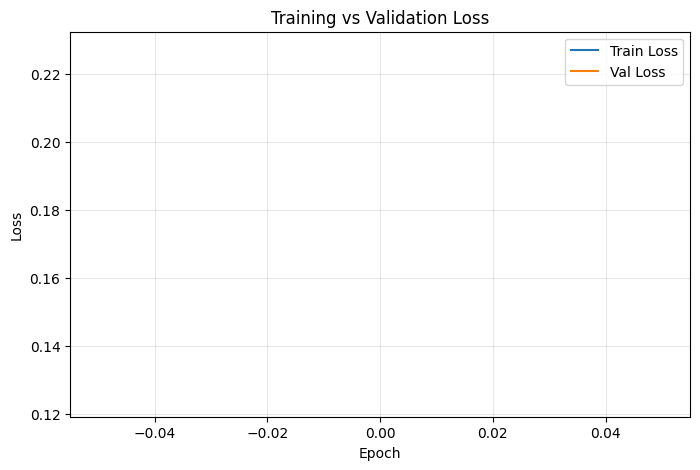

Epoch 2/100 | train_loss: 0.1063 | val_loss: 0.1030 | val_f1: 0.9707 | val_acc: 0.9715


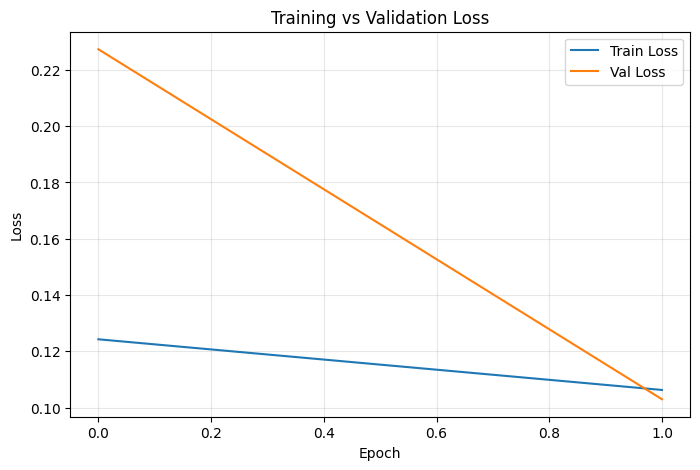

Epoch 3/100 | train_loss: 0.1051 | val_loss: 0.0854 | val_f1: 0.9723 | val_acc: 0.9729


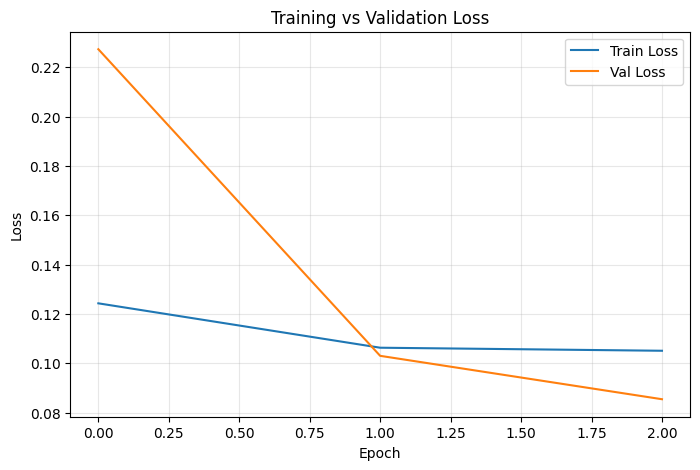

Epoch 4/100 | train_loss: 0.1022 | val_loss: 0.1820 | val_f1: 0.9208 | val_acc: 0.9257


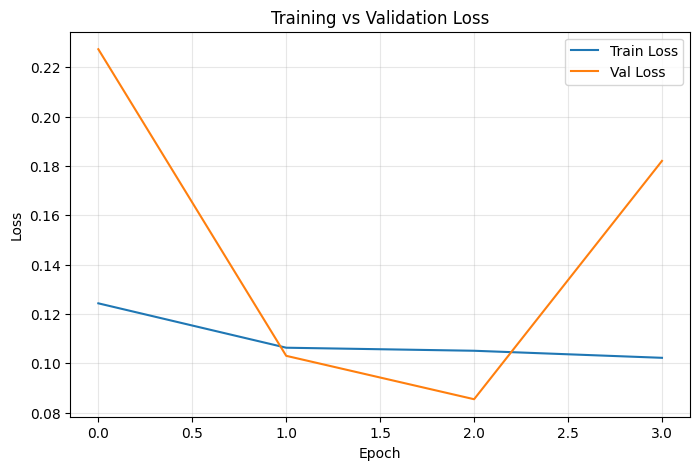

Epoch 5/100 | train_loss: 0.0950 | val_loss: 0.1064 | val_f1: 0.9580 | val_acc: 0.9596


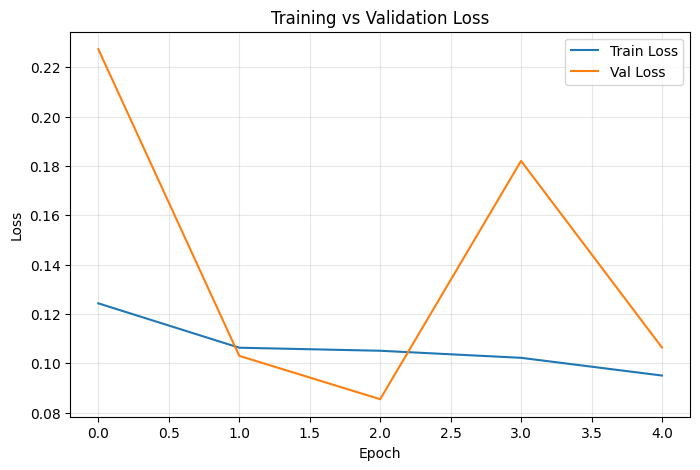

Epoch 6/100 | train_loss: 0.0865 | val_loss: 0.1429 | val_f1: 0.9429 | val_acc: 0.9459


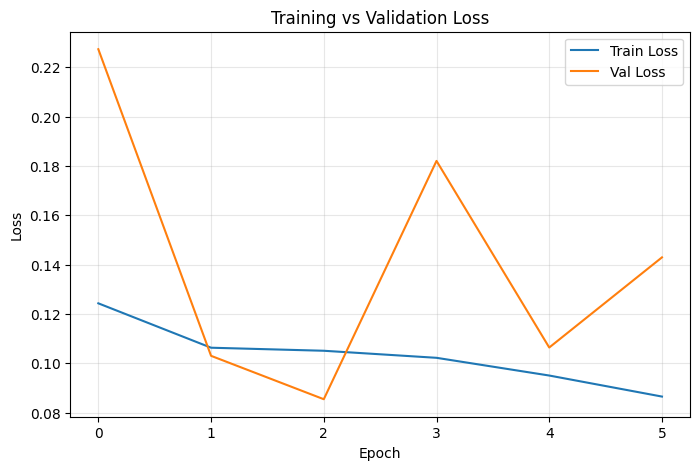

Epoch 7/100 | train_loss: 0.0917 | val_loss: 0.1733 | val_f1: 0.9228 | val_acc: 0.9277


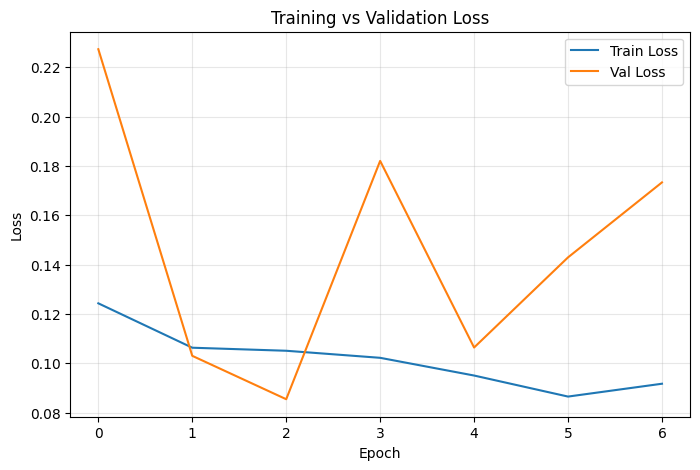

Epoch 8/100 | train_loss: 0.0723 | val_loss: 0.2214 | val_f1: 0.9020 | val_acc: 0.9094


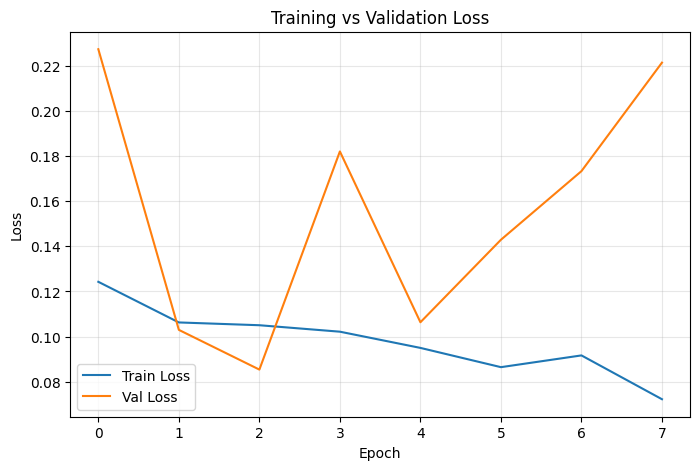

Epoch 9/100 | train_loss: 0.0677 | val_loss: 0.1678 | val_f1: 0.9285 | val_acc: 0.9326


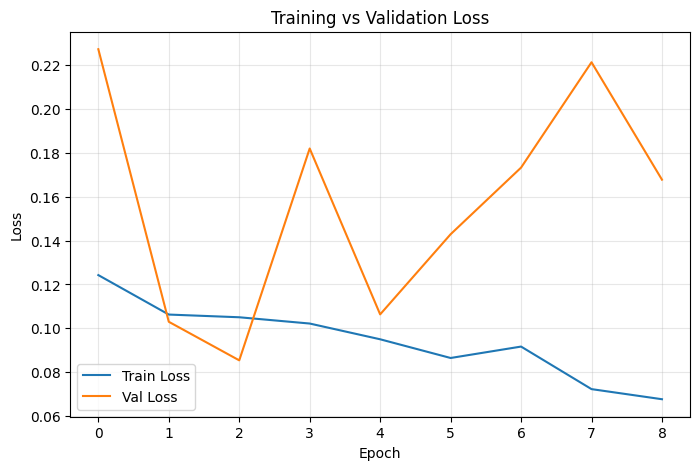

Epoch 10/100 | train_loss: 0.0699 | val_loss: 0.1248 | val_f1: 0.9588 | val_acc: 0.9596


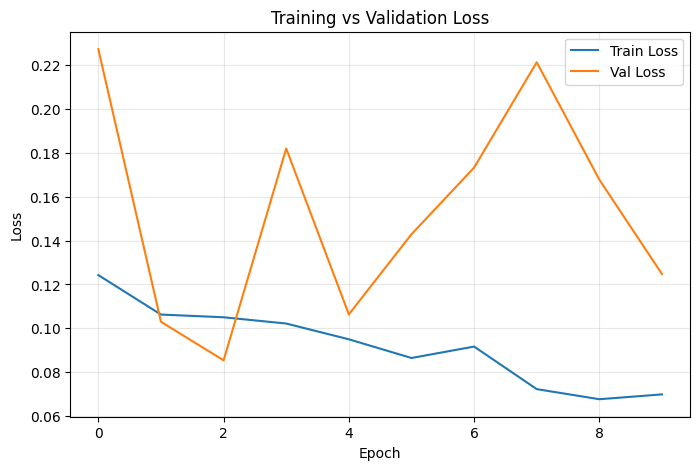

Epoch 11/100 | train_loss: 0.0642 | val_loss: 0.0986 | val_f1: 0.9661 | val_acc: 0.9670


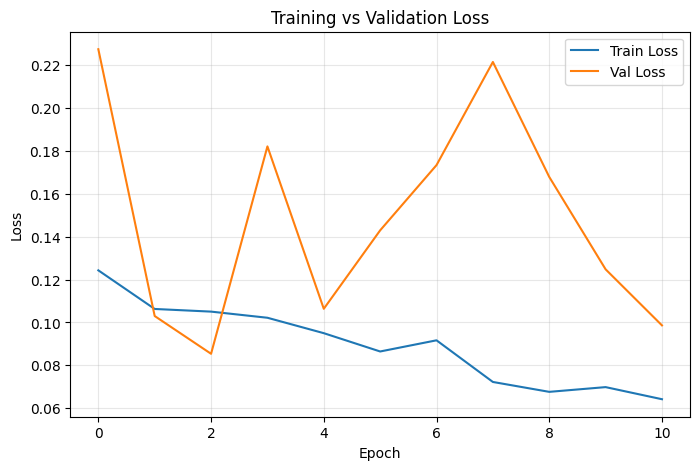

Epoch 12/100 | train_loss: 0.0561 | val_loss: 0.2020 | val_f1: 0.9175 | val_acc: 0.9222


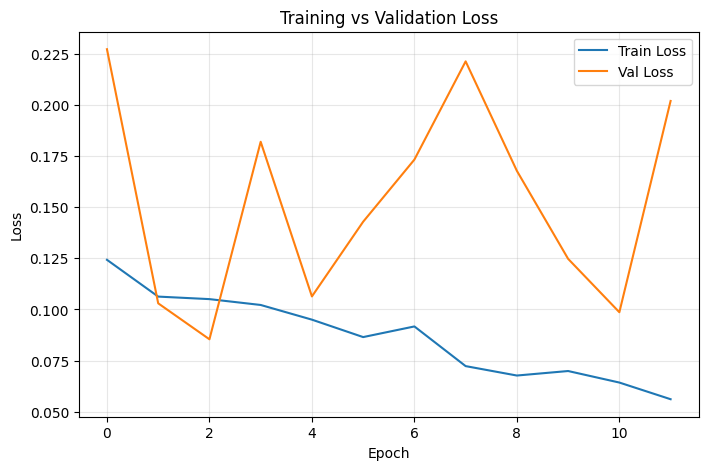

Epoch 13/100 | train_loss: 0.0544 | val_loss: 0.1837 | val_f1: 0.9301 | val_acc: 0.9341


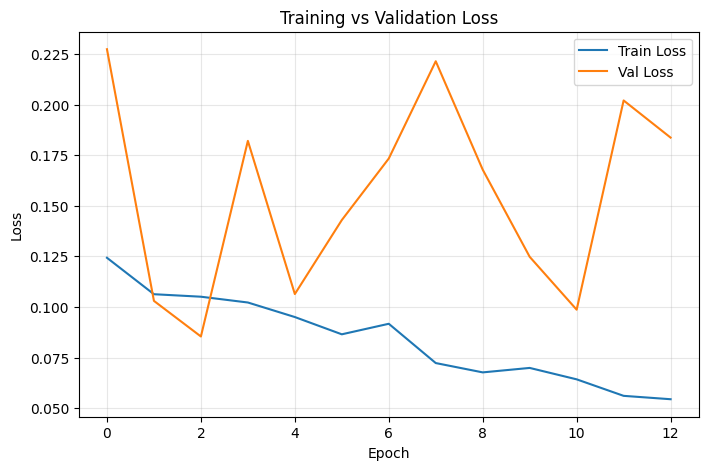

Epoch 14/100 | train_loss: 0.0589 | val_loss: 0.1171 | val_f1: 0.9569 | val_acc: 0.9582


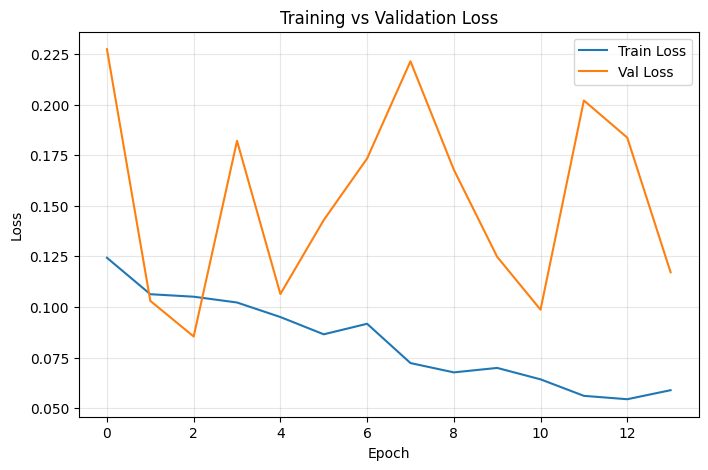

Epoch 15/100 | train_loss: 0.0547 | val_loss: 0.1248 | val_f1: 0.9508 | val_acc: 0.9528


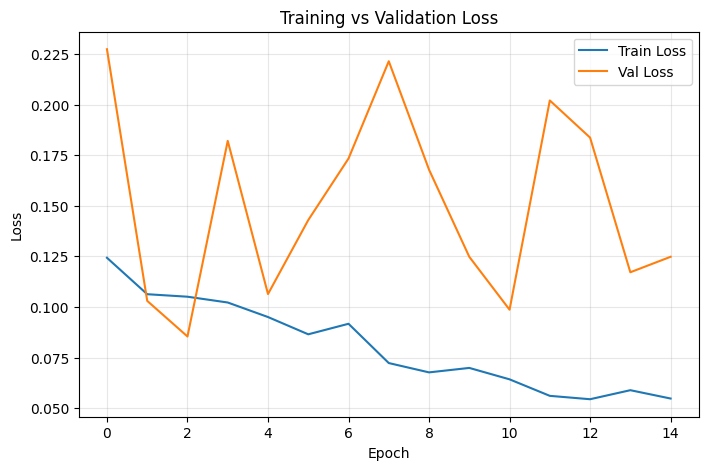

Epoch 16/100 | train_loss: 0.0524 | val_loss: 0.1537 | val_f1: 0.9442 | val_acc: 0.9469


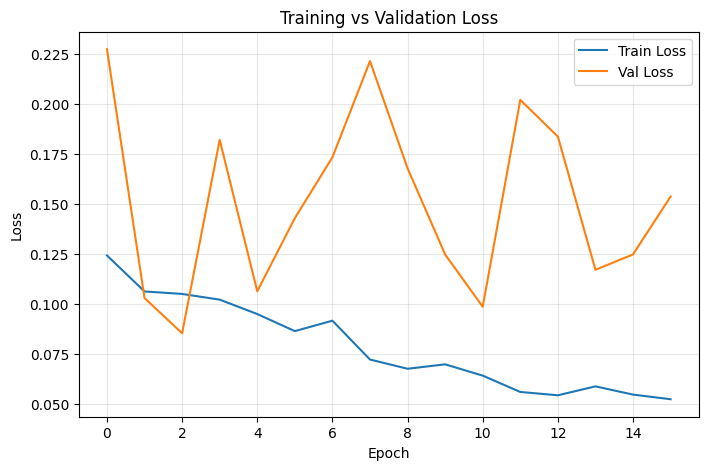

Epoch 17/100 | train_loss: 0.0491 | val_loss: 0.1152 | val_f1: 0.9579 | val_acc: 0.9592


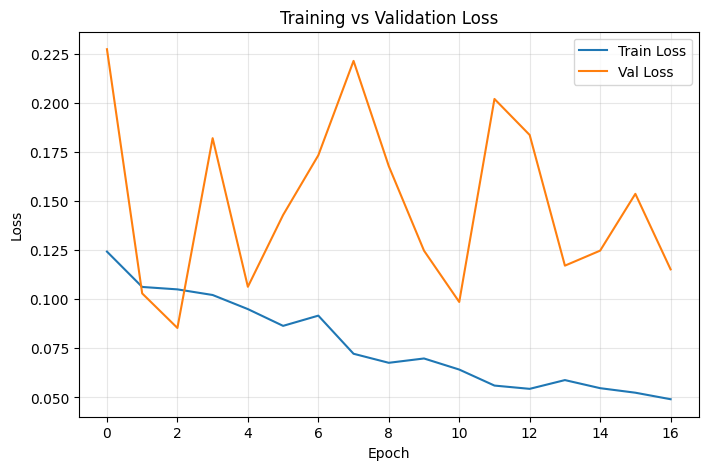

Epoch 18/100 | train_loss: 0.0475 | val_loss: 0.1596 | val_f1: 0.9431 | val_acc: 0.9459


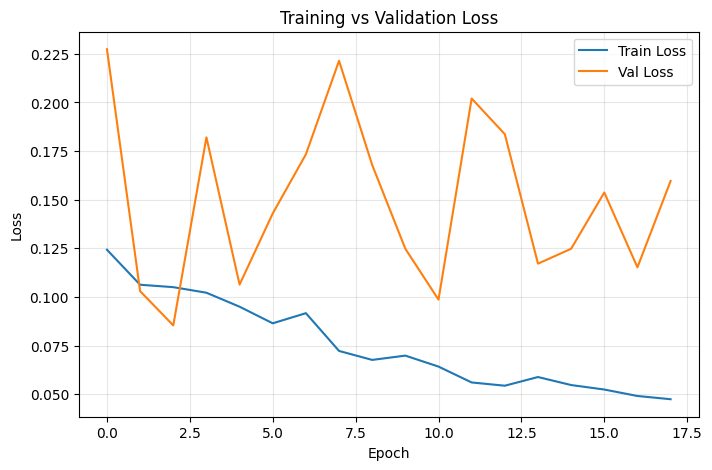

Epoch 19/100 | train_loss: 0.0481 | val_loss: 0.1402 | val_f1: 0.9477 | val_acc: 0.9498


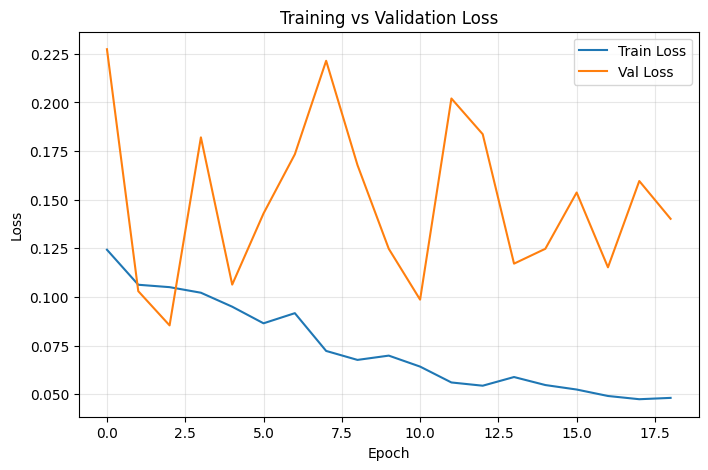

Epoch 20/100 | train_loss: 0.0438 | val_loss: 0.1741 | val_f1: 0.9385 | val_acc: 0.9414


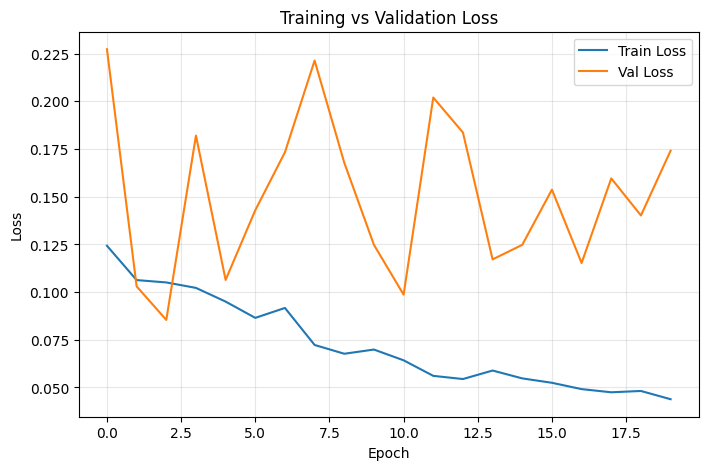

Epoch 21/100 | train_loss: 0.0411 | val_loss: 0.2371 | val_f1: 0.9134 | val_acc: 0.9198


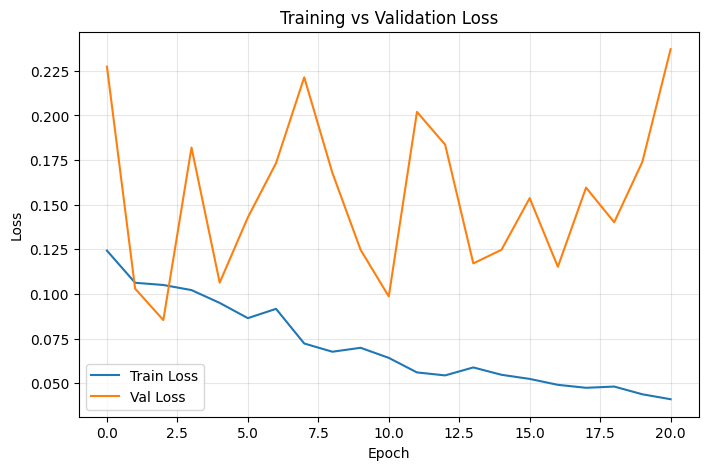

Epoch 22/100 | train_loss: 0.0435 | val_loss: 0.1836 | val_f1: 0.9333 | val_acc: 0.9370


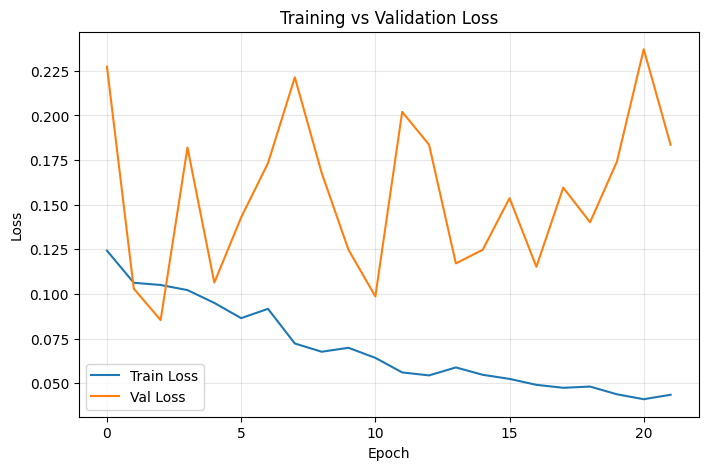

Epoch 23/100 | train_loss: 0.0459 | val_loss: 0.1370 | val_f1: 0.9531 | val_acc: 0.9547


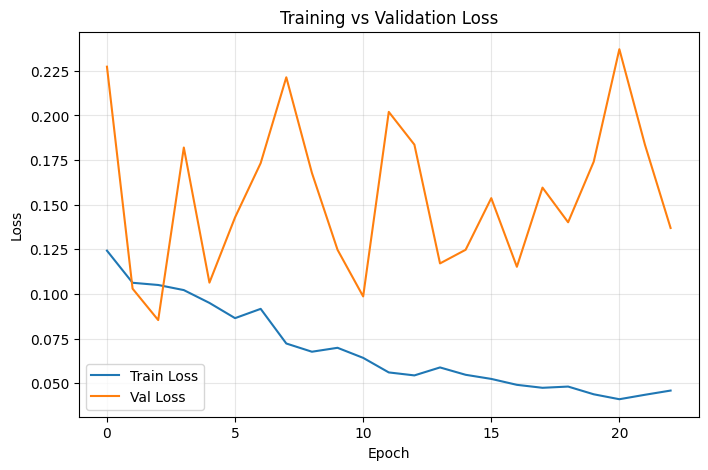

Early stopping at epcoch: 23
Best epoch: 3 | val_loss: 0.0854 | val_metrics: {'accuracy': 0.9729330539703369, 'auroc': 0.9948200583457947, 'f1': 0.9722921848297119, 'precision': 0.9816886782646179, 'recall': 0.9630738496780396}


In [26]:

model = myCNN.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

num_epochs = 100
best_val_loss = float("inf")
patience = 20
epochs_no_improve = 0
best_state = None
best_val_metrics = None
best_epoch = None
history_dict = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[]}

for epoch in range(num_epochs):

    train_loss = train_for_one_epoch(model, train_loader, device, aug, optimizer, criterion)
    val_loss, val_metrics = val_for_one_epoch(model, val_loader, metrics, device, criterion)

    history_dict["train_loss"].append(train_loss)
    history_dict["val_loss"].append(val_loss)
    history_dict["val_accuracy"].append(val_metrics["accuracy"])
    history_dict["val_f1"].append(val_metrics["f1"])
    history_dict["val_precision"].append(val_metrics["precision"])
    history_dict["val_recall"].append(val_metrics["recall"])
    history_dict["val_auroc"].append(val_metrics["auroc"])

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
          f"| val_f1: {val_metrics['f1']:.4f} | val_acc: {val_metrics['accuracy']:.4f}")

    plot_and_save_loss(history_dict, loss_curve_fp)

    # Early stopping

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_metrics = val_metrics
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve +=1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epcoch: {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"Best epoch: {best_epoch+1} | val_loss: {best_val_loss:.4f} | val_metrics: {best_val_metrics}")




In [ ]:
test_dataset = PatchDataset(patches = train_patches, labels = train_labels, mean = mean, std = std)

test_loader = DataLoader(
    dataset= train_dataset,
    shuffle= True,
    batch_size= 32,
    num_workers= 2,
    pin_memory= True
    )

for batch_X, batch_y in test_loader:
    model.eval()
    running_val_loss = 0.0
    metrics.reset() # clears the metrics from previous epochs

    with torch.no_grad():
        for batch_X, batch_y in val_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)               # Outputting logits as useing BCEntropy with logit loss as criterion
            val_loss = criterion(logits, batch_y)

            #probs = torch.sigmoid(logits) # gives probabilities between 0 and 1
            #preds = (logits >= 0).int() #because sigmoid(0) = 0.5 and would use as probability threshold anyway
            metrics.update(logits, batch_y) # accumulates the metrics per batch. Torchmetrics detects logits and applies sigmoid internally

            running_val_loss += val_loss.item()*batch_X.size(0)


        avg_loss = running_val_loss / len(val_loader.dataset)
        results = {k: v.item() for k, v in metrics.compute().items()}

